# Лабораторна робота №3

## Побудова та оцінювання моделі лінійної регресії

**Тема:** прогнозування витрати пального автомобіля за технічними характеристиками.

**Мета:** побудувати модель лінійної регресії для прогнозування показника `mpg`, порівняти її з базовою моделлю та оцінити якість за метриками MAE, RMSE і R².

**Студент:** Михайло Вахнюк   
**Група:** МІТ-31  
**Набір даних:** Auto MPG  
**Джерело:** https://archive.ics.uci.edu/dataset/9/auto  
**Ліцензія:** CC BY 4.0  
**Цільова змінна:** `mpg` — кількість миль, яку автомобіль проїжджає на одному галоні пального.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

random_state = 5 

column_names = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "origin",
    "car_name",
]

data_path = Path("auto-mpg.data")
csv_path = Path("auto_mpg.csv")
df = pd.read_csv(
    data_path,
    sep=r"\s+",
    names=column_names,
    na_values="?",
    quotechar='"'
)

df.to_csv(csv_path, index=False)

print("Дані успішно завантажено.")
print("Файл CSV створено:", csv_path.resolve())
display(df.head())

Дані успішно завантажено.
Файл CSV створено: C:\Users\Михайло\Data_Science_Labs\Lab3\auto_mpg.csv


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino




- завантажує початковий файл auto-mpg.data;
- називає його стовпці;
- перетворює символ ? на пропуск NaN;
- створює потрібний CSV-файл auto_mpg.csv у папці Lab3.

In [2]:
print("Розмір таблиці:", df.shape)

print("\nТипи даних:")
print(df.dtypes)

print("\nІнформація про таблицю:")
df.info()

print("\nПерші 5 рядків:")
display(df.head())

print("\nОпис числових стовпців:")
display(df.describe())

print("\nКількість пропусків:")
print(df.isna().sum())

print("\nКількість дублікатів:", df.duplicated().sum())

Розмір таблиці: (398, 9)

Типи даних:
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight          float64
acceleration    float64
model_year        int64
origin            int64
car_name            str
dtype: object

Інформація про таблицю:
<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    str    
dtypes: float64(5), int64(3), str(1)
memory usage: 34.4 KB

Перші 5 рядків:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino



Опис числових стовпців:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000



Кількість пропусків:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

Кількість дублікатів: 0



- shape показує кількість рядків і стовпців;
- dtypes перевіряє тип кожного стовпця;
- info() показує, де є пропуски;
- describe() рахує статистику числових полів;
- isna().sum() рахує пропущені значення;
- duplicated().sum() шукає однакові рядки.

## Первинний аналіз даних

Набір Auto MPG містить 398 автомобілів і 9 стовпців. Цільова змінна `mpg` є числовою та показує паливну ефективність автомобіля в милях на галон. Пропуски можуть бути у стовпці `horsepower`, тому їх не заповнюватимемо вручну до поділу на train і test. Це зробить Pipeline, навчений лише на тренувальній вибірці, і запобігатиме витоку даних.

## Постановка задачі та вибір ознак

Задача моделі — спрогнозувати `mpg`, тобто кількість миль, яку автомобіль проїжджає на одному галоні пального.

Для прогнозування використовуються числові технічні характеристики: кількість циліндрів, об’єм двигуна, потужність, вага, прискорення та рік моделі. Категоріальною ознакою є `origin` — походження автомобіля.

Стовпець `car_name` вилучено, оскільки він містить назву конкретного автомобіля та фактично є ідентифікатором. Його використання може погіршити здатність моделі прогнозувати нові автомобілі.


In [3]:
target_column = "mpg"

numeric_features = [
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
]

categorical_features = ["origin"]

X = df[numeric_features + categorical_features].copy()
y = df[target_column].copy()

print("Форма X:", X.shape)
print("Форма y:", y.shape)

print("\nЧислові ознаки:", numeric_features)
print("Категоріальні ознаки:", categorical_features)
print("Цільова змінна:", target_column)

Форма X: (398, 7)
Форма y: (398,)

Числові ознаки: ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
Категоріальні ознаки: ['origin']
Цільова змінна: mpg


- X — таблиця ознак, за якими модель навчається;
- y — правильні відповіді, які модель намагається передбачити;
- car_name не додаємо до X;
- пропуски ще не заповнюємо: це буде зроблено після train/test поділу всередині Pipeline.

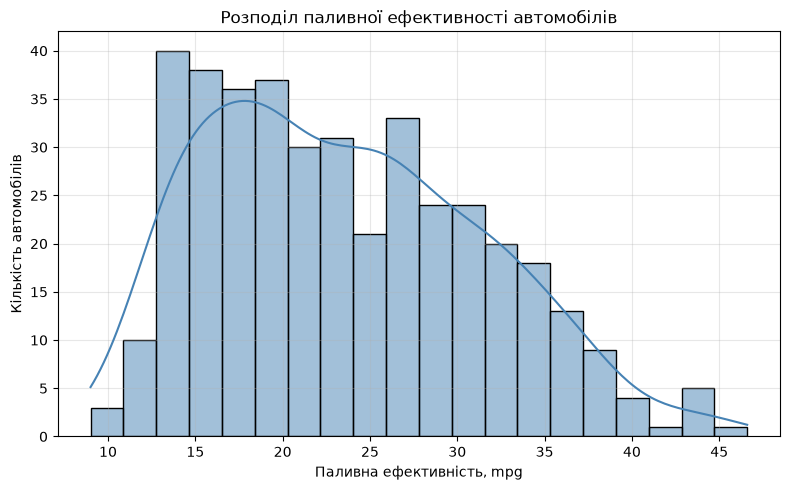

In [4]:
plt.figure(figsize=(8, 5))

sns.histplot(
    y,
    bins=20,
    kde=True,
    color="steelblue"
)

plt.title("Розподіл паливної ефективності автомобілів")
plt.xlabel("Паливна ефективність, mpg")
plt.ylabel("Кількість автомобілів")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

- гістограма показує, скільки автомобілів має певне значення mpg;
- лінія kde=True показує згладжену форму розподілу;
- графік зберігається як target_distribution.png у папці Lab3;


## Розподіл цільової змінної

Цільова змінна `mpg` показує паливну ефективність автомобіля: більше значення означає меншу витрату пального. Гістограма дає змогу оцінити типовий діапазон значень і побачити, чи є дуже рідкісні або крайні спостереження.

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=random_state
)

print("Розмір X_train:", X_train.shape)
print("Розмір X_test:", X_test.shape)
print("Розмір y_train:", y_train.shape)
print("Розмір y_test:", y_test.shape)

Розмір X_train: (318, 7)
Розмір X_test: (80, 7)
Розмір y_train: (318,)
Розмір y_test: (80,)


- 80% даних потрапляє до train — на них модель навчається;
- 20% даних потрапляє до test — на них чесно перевіряємо модель;
- random_state = 5 гарантує, що поділ буде однаковим при кожному запуску;
- тестові дані не використовуються для заповнення пропусків або навчання моделі.

## Поділ на навчальну і тестову вибірки

Дані поділено у співвідношенні 80/20. Навчальна вибірка використовується для навчання моделі, а тестова — лише для остаточної перевірки прогнозів на автомобілях, яких модель не бачила під час навчання.

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessing = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

linear_model = Pipeline([
    ("preprocessing", preprocessing),
    ("regressor", LinearRegression())
])

baseline_model = Pipeline([
    ("preprocessing", preprocessing),
    ("regressor", DummyRegressor(strategy="mean"))
])


- числові пропуски в horsepower будуть заповнюватися медіаною;
- origin обробляється як категорія через OneHotEncoder;
- handle_unknown="ignore" не дає помилки, якщо на тесті трапиться категорія, якої не було під час навчання;
- LinearRegression — основна модель;
- DummyRegressor завжди прогнозує середнє mpg із тренувальних даних. Це базовий орієнтир: наша модель має бути кращою за нього.

## Конвеєр підготовки даних і моделі

Для числових ознак пропуски заповнюються медіаною, а категоріальна ознака `origin` кодується методом One-Hot Encoding. Усі перетворення об’єднано з моделлю в Pipeline, тому вони навчаються лише на тренувальних даних. Це запобігає витоку даних із тестової вибірки.

In [7]:
linear_model.fit(X_train, y_train)
baseline_model.fit(X_train, y_train)

print("Лінійну модель навчено.")
print("Базову DummyRegressor-модель навчено.")

Лінійну модель навчено.
Базову DummyRegressor-модель навчено.


- fit(X_train, y_train) навчає моделі знаходити зв’язок між характеристиками автомобіля та mpg;
- заповнення пропусків і кодування origin також навчаються тільки на X_train;
- X_test і y_test поки що не використовуються — вони залишаються для чесної перевірки.

In [8]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

y_pred_linear = linear_model.predict(X_test)
y_pred_baseline = baseline_model.predict(X_test)

metrics_df = pd.DataFrame({
    "model": ["LinearRegression", "DummyRegressor"],
    "MAE": [
        mean_absolute_error(y_test, y_pred_linear),
        mean_absolute_error(y_test, y_pred_baseline)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_linear)),
        np.sqrt(mean_squared_error(y_test, y_pred_baseline))
    ],
    "R2": [
        r2_score(y_test, y_pred_linear),
        r2_score(y_test, y_pred_baseline)
    ]
})

display(metrics_df.round(3))

,model,MAE,RMSE,R2
0,LinearRegression,2.408,3.282,0.818
1,DummyRegressor,6.383,7.845,-0.038



- обидві моделі роблять прогнози на X_test, якого не бачили під час навчання;
- MAE і RMSE вимірюються в mpg: менше значення — краще;
- R² показує, наскільки модель пояснює зміну mpg: більше значення — краще;
- якщо LinearRegression має менші MAE/RMSE і більше R², ніж DummyRegressor, вона справді корисніша за простий прогноз середнього.

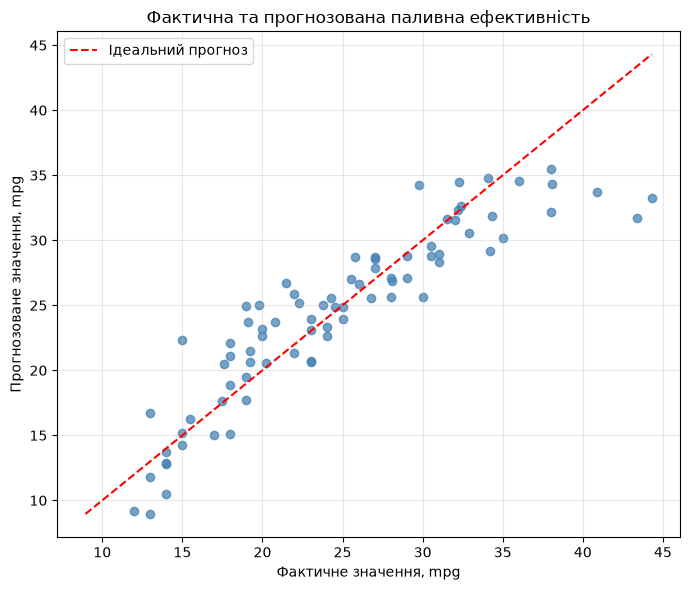

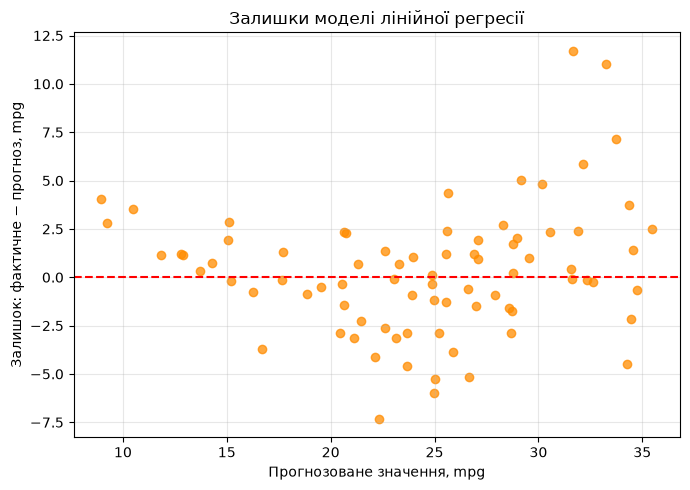

In [9]:
residuals = y_test - y_pred_linear

# Графік 2: фактичні значення проти прогнозованих
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    y_test,
    y_pred_linear,
    color="steelblue",
    alpha=0.75
)

min_value = min(y_test.min(), y_pred_linear.min())
max_value = max(y_test.max(), y_pred_linear.max())

ax.plot(
    [min_value, max_value],
    [min_value, max_value],
    color="red",
    linestyle="--",
    label="Ідеальний прогноз"
)

ax.set_title("Фактична та прогнозована паливна ефективність")
ax.set_xlabel("Фактичне значення, mpg")
ax.set_ylabel("Прогнозоване значення, mpg")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig("actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()


# Графік 3: залишки відносно прогнозу
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    y_pred_linear,
    residuals,
    color="darkorange",
    alpha=0.75
)

ax.axhline(
    y=0,
    color="red",
    linestyle="--"
)

ax.set_title("Залишки моделі лінійної регресії")
ax.set_xlabel("Прогнозоване значення, mpg")
ax.set_ylabel("Залишок: фактичне − прогноз, mpg")
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig("residuals_plot.png", dpi=300, bbox_inches="tight")
plt.show()


- на першому графіку точки ближче до червоної лінії означають точніший прогноз;
- на графіку залишків точки мають бути хаотично розкидані навколо нуля;
- явна дуга, нахил або різне розсіювання залишків може означати, що лінійна модель не описує всі залежності;
- PNG-файли збережуться в папці Lab3.

In [10]:
test_predictions = pd.DataFrame({
    "actual_mpg": y_test.to_numpy(),
    "predicted_mpg": y_pred_linear,
    "residual": residuals.to_numpy(),
    "absolute_error": np.abs(residuals.to_numpy())
})

test_predictions.to_csv(
    "test_predictions.csv",
    index=False
)

metrics_df.to_csv(
    "metrics.csv",
    index=False
)

print("Збережено:", Path("test_predictions.csv").resolve())
print("Збережено:", Path("metrics.csv").resolve())

display(test_predictions.head())
display(metrics_df.round(3))

Збережено: C:\Users\Михайло\Data_Science_Labs\Lab3\test_predictions.csv
Збережено: C:\Users\Михайло\Data_Science_Labs\Lab3\metrics.csv


,actual_mpg,predicted_mpg,residual,absolute_error
0,25.8,28.679597,-2.879597,2.879597
1,44.3,33.259066,11.040934,11.040934
2,29.0,28.768804,0.231196,0.231196
3,28.0,25.608882,2.391118,2.391118
4,17.6,20.464998,-2.864998,2.864998


,model,MAE,RMSE,R2
0,LinearRegression,2.408,3.282,0.818
1,DummyRegressor,6.383,7.845,-0.038



- test_predictions.csv містить фактичні значення mpg, прогнози, залишки та абсолютні помилки;
- metrics.csv містить порівняння LinearRegression і DummyRegressor;
- ці два файли є обов’язковими результатами ЛР3;
- index=False не додає службовий номер рядка до CSV.

## Оцінювання якості моделей

Лінійна регресія на тестовій вибірці отримала MAE 2.408 mpg, RMSE = 3.282 mpg і R² = 0.818. Базова модель DummyRegressor отримала MAE = 6.383 mpg, RMSE = 7.845 mpg і R² = -0.038.

Лінійна регресія є кращою за базову модель, якщо її MAE та RMSE менші, а R² більше. Найбільші помилки видно за точками, які значно віддалені від червоної діагоналі на графіку фактичних і прогнозованих значень. Якщо залишки розкидані навколо нуля без чіткої форми, модель не має очевидної систематичної похибки.

## Висновок

Було побудовано модель лінійної регресії для прогнозування паливної ефективності автомобілів у mpg за технічними характеристиками. Дані було поділено на навчальну і тестову вибірки, а обробку пропусків і категоріальної ознаки виконано в Pipeline без витоку даних. Якість моделі оцінено за MAE, RMSE та R² і порівняно з DummyRegressor. Обмеженням моделі є припущення про лінійний зв’язок між ознаками та витратою пального. Покращити результат можна додаванням нових ознак або застосуванням нелінійних моделей.